# 🏥 PRESENTACIÓN: LIMPIEZA DE DATASET MÉDICO

## **Predicción de Supervivencia Hospitalaria UCI**
### 📊 Dataset: 91,713 pacientes con 85 variables
### 🎯 Objetivo: Limpieza completa para Machine Learning

---

## 📋 CONTENIDO DE LA PRESENTACIÓN

1. **Análisis del Dataset Original** - Exploración inicial y detección de problemas
2. **Identificación de Valores Faltantes** - Análisis detallado de missing values
3. **Explicación del Script de Limpieza** - Revisión del código `clean_dataset_complete.py`
4. **Ejecución del Proceso de Limpieza** - Demostración en tiempo real
5. **Comparación Antes vs Después** - Visualización de resultados
6. **Justificación de Metodologías** - Explicación de decisiones técnicas

---

## 1️⃣ ANÁLISIS DEL DATASET ORIGINAL

### Cargando las librerías necesarias

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print("📚 Librerías cargadas exitosamente")
print("🎨 Configuración de visualización lista")

📚 Librerías cargadas exitosamente
🎨 Configuración de visualización lista


### 📊 Carga y primera exploración del dataset

In [19]:
# Cargar el dataset original
df_original = pd.read_csv('dataset.csv')

print("=" * 60)
print("📊 DATASET MÉDICO - INFORMACIÓN GENERAL")
print("=" * 60)
print(f"📈 Dimensiones: {df_original.shape[0]:,} filas × {df_original.shape[1]} columnas")
print(f"💾 Tamaño en memoria: {df_original.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"🎯 Variable objetivo: hospital_death")

# Información sobre la variable objetivo
if 'hospital_death' in df_original.columns:
    mortality_rate = df_original['hospital_death'].mean() * 100
    survivors = (df_original['hospital_death'] == 0).sum()
    deaths = (df_original['hospital_death'] == 1).sum()
    
    print(f"\n🏥 ESTADÍSTICAS DE MORTALIDAD:")
    print(f"   • Supervivientes: {survivors:,} pacientes ({100-mortality_rate:.1f}%)")
    print(f"   • Fallecimientos: {deaths:,} pacientes ({mortality_rate:.1f}%)")
    print(f"   • Tasa de mortalidad UCI: {mortality_rate:.1f}%")


📊 DATASET MÉDICO - INFORMACIÓN GENERAL
📈 Dimensiones: 91,713 filas × 85 columnas
💾 Tamaño en memoria: 90.4 MB
🎯 Variable objetivo: hospital_death

🏥 ESTADÍSTICAS DE MORTALIDAD:
   • Supervivientes: 83,798 pacientes (91.4%)
   • Fallecimientos: 7,915 pacientes (8.6%)
   • Tasa de mortalidad UCI: 8.6%


### 🔍 Visualización de las primeras 20 filas del dataset

In [20]:
print("📋 PRIMERAS 20 FILAS DEL DATASET ORIGINAL")
print("=" * 50)

# Configurar pandas para mostrar TODOS los datos de manera scrolleable
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', None)     # Mostrar todas las filas
pd.set_option('display.width', None)        # Ancho ilimitado
pd.set_option('display.max_colwidth', None) # Ancho de columna ilimitado
pd.set_option('display.expand_frame_repr', False)  # No dividir en líneas

# Mostrar información básica primero
print(f"📊 Total de columnas en el dataset: {df_original.shape[1]}")
print(f"📊 Nombres de todas las columnas:")
columnas = list(df_original.columns)
for i, col in enumerate(columnas, 1):
    print(f"   {i:2d}. {col}")

print(f"\n📋 DATASET COMPLETO - PRIMERAS 20 FILAS:")
print("=" * 100)

# Crear un DataFrame más legible para mostrar
df_display = df_original.head(20).copy()

# ✨ NUEVO: Aplicar estilo para resaltar valores NULO en ROJO/ROSA
def highlight_nulls_red(val):
    """Highlight NULO values in red"""
    if pd.isna(val) or val == 'NULO':
        return 'background-color: #ffcccc; color: #cc0000; font-weight: bold'
    return ''

df_styled = df_display.fillna('NULO').style.applymap(highlight_nulls_red)
display(df_styled)

print(f"\n✅ Se muestran las primeras 20 filas de {df_original.shape[1]} columnas")
print("🔴 Valores en ROJO = Datos faltantes (NULO)")
print("📊 Puedes hacer clic en cualquier celda para ver el valor completo")

# Mostrar algunos ejemplos de valores para verificar la carga correcta
print(f"\n🔍 VERIFICACIÓN DE DATOS CARGADOS:")
print(f"   • Primer encounter_id: {df_original.iloc[0]['encounter_id']}")
print(f"   • Primera edad: {df_original.iloc[0]['age']}")
print(f"   • Primer género: {df_original.iloc[0]['gender']}")
print(f"   • Primer hospital_death: {df_original.iloc[0]['hospital_death']}")

📋 PRIMERAS 20 FILAS DEL DATASET ORIGINAL
📊 Total de columnas en el dataset: 85
📊 Nombres de todas las columnas:
    1. encounter_id
    2. patient_id
    3. hospital_id
    4. age
    5. bmi
    6. elective_surgery
    7. ethnicity
    8. gender
    9. height
   10. icu_admit_source
   11. icu_id
   12. icu_stay_type
   13. icu_type
   14. pre_icu_los_days
   15. weight
   16. apache_2_diagnosis
   17. apache_3j_diagnosis
   18. apache_post_operative
   19. arf_apache
   20. gcs_eyes_apache
   21. gcs_motor_apache
   22. gcs_unable_apache
   23. gcs_verbal_apache
   24. heart_rate_apache
   25. intubated_apache
   26. map_apache
   27. resprate_apache
   28. temp_apache
   29. ventilated_apache
   30. d1_diasbp_max
   31. d1_diasbp_min
   32. d1_diasbp_noninvasive_max
   33. d1_diasbp_noninvasive_min
   34. d1_heartrate_max
   35. d1_heartrate_min
   36. d1_mbp_max
   37. d1_mbp_min
   38. d1_mbp_noninvasive_max
   39. d1_mbp_noninvasive_min
   40. d1_resprate_max
   41. d1_resprate_mi

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,heart_rate_apache,intubated_apache,map_apache,resprate_apache,temp_apache,ventilated_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,d1_glucose_max,d1_glucose_min,d1_potassium_max,d1_potassium_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.000000,22.730000,0,Caucasian,M,180.300000,Floor,92,admit,CTICU,0.541667,73.900000,113.000000,502.010000,0,0.000000,3.000000,6.000000,0.000000,4.000000,118.000000,0.000000,40.000000,36.000000,39.300000,0.000000,68.000000,37.000000,68.000000,37.000000,119.000000,72.000000,89.000000,46.000000,89.000000,46.000000,34.000000,10.000000,100.000000,74.000000,131.000000,73.000000,131.000000,73.000000,39.900000,37.200000,68.000000,63.000000,68.000000,63.000000,119.000000,108.000000,86.000000,85.000000,86.000000,85.000000,26.000000,18.000000,100.000000,74.000000,131.000000,115.000000,131.000000,115.000000,168.000000,109.000000,4.000000,3.400000,0.100000,0.050000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Sepsis,Cardiovascular,NULO,0
1,114252,59342,81,77.000000,27.420000,0,Caucasian,F,160.000000,Floor,90,admit,Med-Surg ICU,0.927778,70.200000,108.000000,203.010000,0,0.000000,1.000000,3.000000,0.000000,1.000000,120.000000,0.000000,46.000000,33.000000,35.100000,1.000000,95.000000,31.000000,95.000000,31.000000,118.000000,72.000000,120.000000,38.000000,120.000000,38.000000,32.000000,12.000000,100.000000,70.000000,159.000000,67.000000,159.000000,67.000000,36.300000,35.100000,61.000000,48.000000,61.000000,48.000000,114.000000,100.000000,85.000000,57.000000,85.000000,57.000000,31.000000,28.000000,95.000000,70.000000,95.000000,71.000000,95.000000,71.000000,145.000000,128.000000,4.200000,3.800000,0.470000,0.290000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Respiratory,Respiratory,NULO,0
2,119783,50777,118,25.000000,31.950000,0,Caucasian,F,172.700000,Accident & Emergency,93,admit,Med-Surg ICU,0.000694,95.300000,122.000000,703.030000,0,0.000000,3.000000,6.000000,0.000000,5.000000,102.000000,0.000000,68.000000,37.000000,36.700000,0.000000,88.000000,48.000000,88.000000,48.000000,96.000000,68.000000,102.000000,68.000000,102.000000,68.000000,21.000000,8.000000,98.000000,91.000000,148.000000,105.000000,148.000000,105.000000,37.000000,36.700000,88.000000,58.000000,88.000000,58.000000,96.000000,78.000000,91.000000,83.000000,91.000000,83.000000,20.000000,16.000000,98.000000,91.000000,148.000000,124.000000,148.000000,124.000000,NULO,NULO,NULO,NULO,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Metabolic,Metabolic,NULO,0
3,79267,46918,118,81.000000,22.640000,1,Caucasian,F,165.100000,Operating Room / Recovery,92,admit,CTICU,0.000694,61.700000,203.000000,1206.030000,1,0.000000,4.000000,6.000000,0.000000,5.000000,114.000000,1.000000,60.000000,4.000000,34.800000,1.000000,48.000000,42.000000,48.000000,42.000000,116.000000,92.00000


✅ Se muestran las primeras 20 filas de 85 columnas
🔴 Valores en ROJO = Datos faltantes (NULO)
📊 Puedes hacer clic en cualquier celda para ver el valor completo

🔍 VERIFICACIÓN DE DATOS CARGADOS:
   • Primer encounter_id: 66154
   • Primera edad: 68.0
   • Primer género: M
   • Primer hospital_death: 0


## 2️⃣ IDENTIFICACIÓN DETALLADA DE VALORES FALTANTES

### 🕵️ Análisis exhaustivo de missing values

In [21]:
print("🔍 ANÁLISIS DETALLADO DE VALORES FALTANTES")
print("=" * 60)

# Calcular missing values por columna
missing_data = df_original.isnull().sum()
missing_percent = (missing_data / len(df_original)) * 100

# Crear DataFrame con información de missing values
missing_df = pd.DataFrame({
    'Columna': missing_data.index,
    'Valores_Faltantes': missing_data.values,
    'Porcentaje': missing_percent.values,
    'Tipo_Dato': [str(df_original[col].dtype) for col in missing_data.index]
})

# Filtrar solo columnas con missing values
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0]
missing_df = missing_df.sort_values('Valores_Faltantes', ascending=False)

print(f"📊 Total de valores faltantes en el dataset: {missing_data.sum():,}")
print(f"📊 Porcentaje total missing: {(missing_data.sum() / df_original.size) * 100:.2f}%")
print(f"📊 Columnas con valores faltantes: {len(missing_df)}")

print("\n🎯 TABLA COMPLETA DE COLUMNAS CON VALORES FALTANTES:")
print("-" * 80)

# Configurar display para mostrar toda la tabla
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Mostrar tabla completa con scroll en Colab
if len(missing_df) > 0:
    # Agregar categoría de severidad
    missing_df['Severidad'] = missing_df['Porcentaje'].apply(
        lambda x: '🔴 CRÍTICO' if x > 50 else
                  '🟠 ALTO' if x > 20 else
                  '🟡 MODERADO' if x > 5 else
                  '🔵 BAJO'
    )
    
    # Reorganizar columnas para mejor visualización
    missing_display = missing_df[['Columna', 'Valores_Faltantes', 'Porcentaje', 'Severidad', 'Tipo_Dato']].copy()
    missing_display['Porcentaje'] = missing_display['Porcentaje'].round(2)
    
    # Mostrar tabla completa
    missing_display = missing_display.fillna('NULO')
    display(missing_display)
    
    print(f"\n📈 RESUMEN POR SEVERIDAD:")
    severidad_counts = missing_df['Severidad'].value_counts()
    for sev, count in severidad_counts.items():
        print(f"   {sev}: {count} columnas")
    
    # Mostrar ejemplos específicos de cada fila con missing values
    print(f"\n🔍 EJEMPLOS DE FILAS CON VALORES FALTANTES:")
    print("-" * 60)
    
    # Tomar las primeras 5 columnas más problemáticas
    top_problematic = missing_df.head(5)['Columna'].tolist()
    
    for i, col in enumerate(top_problematic, 1):
        # Encontrar una fila que tenga missing en esta columna
        missing_rows = df_original[df_original[col].isnull()].index[:3]  # Primeras 3 filas con missing
        
        print(f"\\n{i}. Columna: {col}")
        print(f"   Filas con missing (ejemplos): {list(missing_rows)}")
        
        if len(missing_rows) > 0:
            row_idx = missing_rows[0]
            print(f"   Ejemplo fila {row_idx}:")
            # Mostrar algunos valores de contexto de esa fila
            context_cols = ['encounter_id', 'age', 'gender', col, 'hospital_death']
            available_cols = [c for c in context_cols if c in df_original.columns]
            
            for context_col in available_cols:
                valor = df_original.iloc[row_idx][context_col]
                if pd.isna(valor):
                    print(f"     {context_col}: ❌ MISSING")
                else:
                    print(f"     {context_col}: {valor}")

else:
    print("✅ ¡No hay valores faltantes en el dataset!")

print(f"\n📋 TOTAL DE COLUMNAS ANALIZADAS: {len(df_original.columns)}")
print(f"📋 COLUMNAS SIN MISSING VALUES: {len(df_original.columns) - len(missing_df)}")

🔍 ANÁLISIS DETALLADO DE VALORES FALTANTES
📊 Total de valores faltantes en el dataset: 288,046
📊 Porcentaje total missing: 3.69%
📊 Columnas con valores faltantes: 75

🎯 TABLA COMPLETA DE COLUMNAS CON VALORES FALTANTES:
--------------------------------------------------------------------------------


,Columna,Valores_Faltantes,Porcentaje,Severidad,Tipo_Dato
83,Unnamed: 83,91713,100.00,🔴 CRÍTICO,float64
69,d1_potassium_max,9585,10.45,🟡 MODERADO,float64
70,d1_potassium_min,9585,10.45,🟡 MODERADO,float64
58,h1_mbp_noninvasive_min,9084,9.90,🟡 MODERADO,float64
57,h1_mbp_noninvasive_max,9084,9.90,🟡 MODERADO,float64
71,apache_4a_hospital_death_prob,7947,8.67,🟡 MODERADO,float64
72,apache_4a_icu_death_prob,7947,8.67,🟡 MODERADO,float64
51,h1_diasbp_noninvasive_max,7350,8.01,🟡 MODERADO,float64
52,h1_diasbp_noninvasive_min,7350,8.01,🟡 MODERADO,float64
65,h1_sysbp_noninvasive_max,7341,8.00,🟡 MODERADO,float64



📈 RESUMEN POR SEVERIDAD:
   🔵 BAJO: 60 columnas
   🟡 MODERADO: 14 columnas
   🔴 CRÍTICO: 1 columnas

🔍 EJEMPLOS DE FILAS CON VALORES FALTANTES:
------------------------------------------------------------
\n1. Columna: Unnamed: 83
   Filas con missing (ejemplos): [0, 1, 2]
   Ejemplo fila 0:
     encounter_id: 66154
     age: 68.0
     gender: M
     Unnamed: 83: ❌ MISSING
     hospital_death: 0
\n2. Columna: d1_potassium_max
   Filas con missing (ejemplos): [2, 4, 12]
   Ejemplo fila 2:
     encounter_id: 119783
     age: 25.0
     gender: F
     d1_potassium_max: ❌ MISSING
     hospital_death: 0
\n3. Columna: d1_potassium_min
   Filas con missing (ejemplos): [2, 4, 12]
   Ejemplo fila 2:
     encounter_id: 119783
     age: 25.0
     gender: F
     d1_potassium_min: ❌ MISSING
     hospital_death: 0
\n4. Columna: h1_mbp_noninvasive_min
   Filas con missing (ejemplos): [3, 14, 19]
   Ejemplo fila 3:
     encounter_id: 79267
     age: 81.0
     gender: F
     h1_mbp_noninvasive_min: ❌ M

### 📊 Visualización de la distribución de valores faltantes

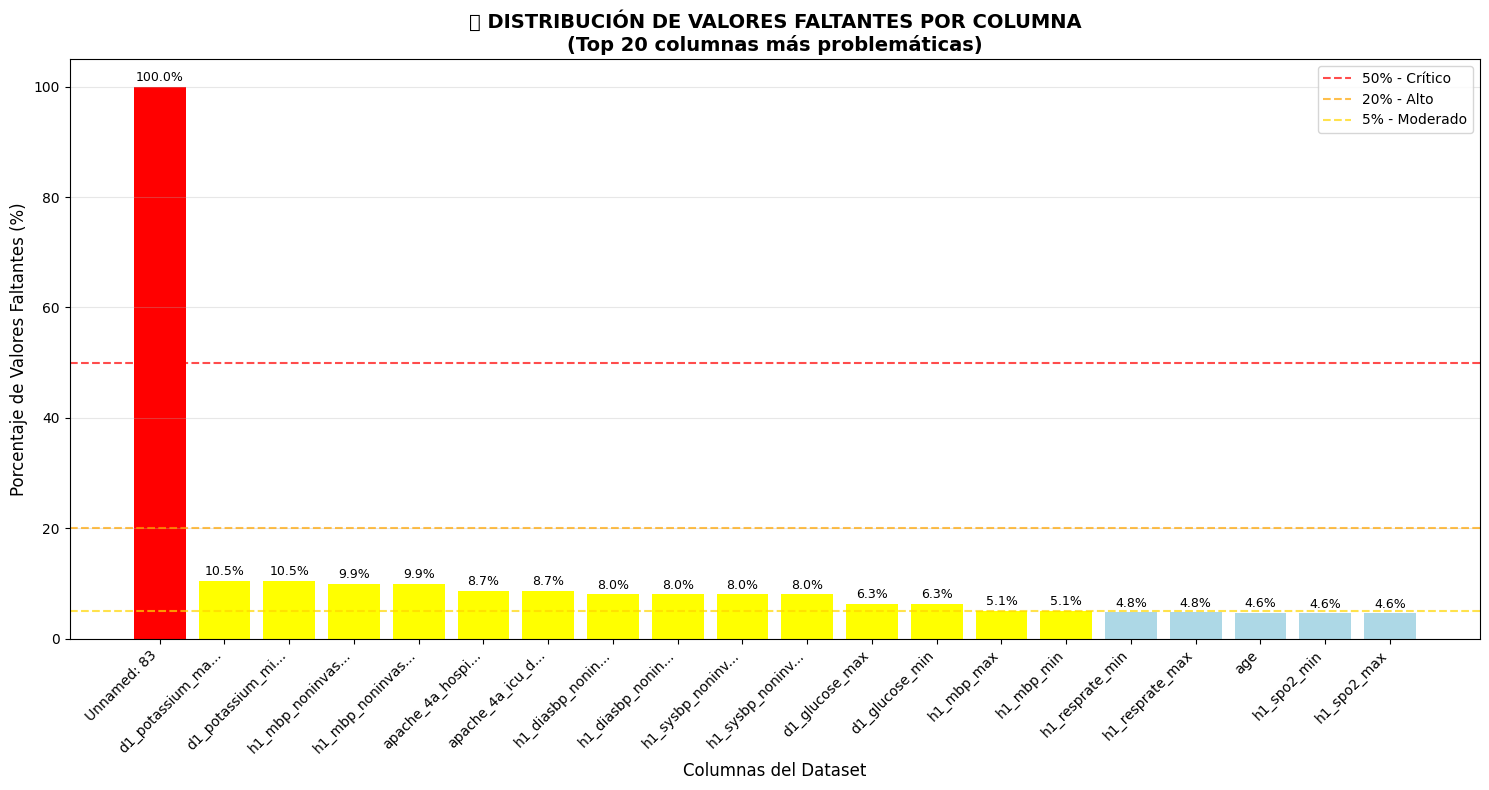

🎨 Gráfico generado exitosamente
🔴 Rojo: >50% missing (crítico)
🟠 Naranja: 20-50% missing (alto)
🟡 Amarillo: 5-20% missing (moderado)
🔵 Azul: <5% missing (bajo)


In [22]:
# Gráfico de barras con las columnas más problemáticas
plt.figure(figsize=(15, 8))

top_missing = missing_df.head(20)
bars = plt.bar(range(len(top_missing)), top_missing['Porcentaje'], 
               color=['red' if x > 50 else 'orange' if x > 20 else 'yellow' if x > 5 else 'lightblue' 
                      for x in top_missing['Porcentaje']])

plt.xlabel('Columnas del Dataset', fontsize=12)
plt.ylabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
plt.title('🔍 DISTRIBUCIÓN DE VALORES FALTANTES POR COLUMNA\n(Top 20 columnas más problemáticas)', 
          fontsize=14, fontweight='bold')

# Añadir etiquetas en las barras
for i, (bar, pct) in enumerate(zip(bars, top_missing['Porcentaje'])):
    if pct > 1:  # Solo mostrar porcentajes > 1%
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.xticks(range(len(top_missing)), 
           [col[:15] + '...' if len(col) > 15 else col for col in top_missing['Columna']], 
           rotation=45, ha='right')

# Añadir líneas de referencia
plt.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% - Crítico')
plt.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='20% - Alto')
plt.axhline(y=5, color='gold', linestyle='--', alpha=0.7, label='5% - Moderado')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("🎨 Gráfico generado exitosamente")
print("🔴 Rojo: >50% missing (crítico)")
print("🟠 Naranja: 20-50% missing (alto)")
print("🟡 Amarillo: 5-20% missing (moderado)")
print("🔵 Azul: <5% missing (bajo)")

### 🧮 Análisis de patrones de missing values por categorías

## 3️⃣ EXPLICACIÓN DEL SCRIPT DE LIMPIEZA

### 📝 Revisión del código `clean_dataset_complete.py`

## 🎯 ¿Qué son los OUTLIERS?

### 📌 Definición Simple
**Outliers** = Valores **extremadamente diferentes** al resto de los datos

### 🏥 Ejemplo Médico Práctico

Imagina que mides la **frecuencia cardíaca** de 10 pacientes en una sala de espera:

```
Pacientes normales:     72, 75, 68, 80, 78, 71, 76, 73 lpm  ✅
Paciente en crisis:     155 lpm                              🚨
Paciente crítico:       180 lpm                              🚨
```

→ Los valores **155** y **180** son **OUTLIERS** (valores atípicos)

### ❓ ¿Por qué importa en Machine Learning?

| Estadístico | ¿Se afecta por outliers? | Ejemplo |
|-------------|-------------------------|----------|
| **MEDIA** (promedio) | ✅ SÍ - Se distorsiona | 72→75→180 = 109 lpm ❌ (no representa la realidad) |
| **MEDIANA** (valor central) | ❌ NO - Se mantiene estable | 72→75→180 = 75 lpm ✅ (representa mejor) |

### 💡 Por eso el script usa MEDIANA
En datos médicos, los outliers son **informativos** (pacientes críticos) pero **no representativos** del paciente típico.


---

## ✅ CONCLUSIÓN: ¿Por qué usar MEDIANA en lugar de MEDIA?

### 🏥 Aplicación al Dataset Médico:

✅ **MEDIANA** (elegida en el script):
- Robusta ante pacientes críticos
- Representa al paciente "típico"
- No se distorsiona por valores extremos

❌ **MEDIA** (descartada):
- Se infla con casos críticos
- No representa la realidad clínica
- Generaría imputaciones erróneas

### 📊 Impacto en 91,713 pacientes:
Usar mediana preserva la **distribución real** de signos vitales, evitando distorsiones que afectarían la predicción de mortalidad.

---

### 🔬 **DETALLE TÉCNICO: ¿Por qué el BMI tiene tratamiento especial?**

#### 📐 **Fórmula del BMI**
```
BMI = peso (kg) / (altura (m))²
```

#### 🤔 **El dilema del médico en urgencias**

Imagina un médico en la UCI:
- ⏰ Tiene **poco tiempo** (paciente crítico)
- 📝 Ingresa datos: **peso = 73.9 kg**, **altura = 180.3 cm**
- 🤷 ¿Calculará mentalmente el BMI? **Probablemente NO**
- 🏃 Pasa al siguiente paciente → **BMI queda vacío**

#### 💡 **Nuestra solución inteligente**

**PASO 1:** Antes de rellenar con mediana, el código **busca**:
- ¿Falta el BMI? ✅
- ¿Pero HAY peso y altura? → **Calculamos el BMI**

**PASO 2:** Si tampoco hay peso/altura:
- Usamos mediana = 27.65

#### 📊 **Resultado en este dataset**

```python
Total BMI faltantes: 3.429
Casos calculables (peso + altura disponibles): 0  # Siempre que falta BMI, también falta peso o altura
Casos rellenados con mediana: 3.429
```

**Conclusión:** En este dataset específico, cuando falta BMI **SIEMPRE** también falta peso O altura.  
Por eso usamos mediana en los 3,429 casos.

#### ✅ **¿Por qué es importante esta lógica en el código?**

1. **Generalización:** El código funciona para **cualquier dataset médico**
2. **Precisión:** Si en otro dataset hay casos calculables, los aprovecha automáticamente
3. **Transparencia:** El código reporta cuántos valores calculó vs rellenó con mediana
4. **Mejor práctica médica:** Calcular (dato real) > Imputar (estadística) > Eliminar

#### 🎯 **Código implementado en `clean_dataset_complete.py`**

```python
# Paso 1: Intentar calcular BMI desde peso/altura
mask_calcular = df['bmi'].isnull() & df['weight'].notna() & df['height'].notna()
if mask_calcular.sum() > 0:
    df.loc[mask_calcular, 'bmi'] = df.loc[mask_calcular, 'weight'] / ((df.loc[mask_calcular, 'height'] / 100) ** 2)

# Paso 2: Rellenar restantes con mediana
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
```

---

## 4️⃣ EJECUCIÓN DEL PROCESO DE LIMPIEZA

### 🚀 Ejecutando el script en tiempo real

In [23]:
print("🔄 INICIANDO PROCESO DE LIMPIEZA")
print("=" * 60)
print("⚡ Ejecutando clean_dataset_complete.py...")
print("")

# Ejecutar el script de limpieza
import subprocess
import sys
import os

try:
    # Primero verificar si el archivo existe
    script_path = 'clean_dataset_complete.py'
    if os.path.exists(script_path):
        print(f"✅ Archivo encontrado: {script_path}")
        
        # Ejecutar el script desde el directorio correcto
        result = subprocess.run([sys.executable, 'PRESENTACION/clean_dataset_complete.py'], 
                              capture_output=True, text=True, encoding='utf-8', errors='replace', cwd='../')
        
        print("📤 SALIDA DEL SCRIPT:")
        print("-" * 40)
        print(result.stdout)
        
        if result.stderr:
            print("⚠️ WARNINGS/ERRORES:")
            print(result.stderr)
        
        if result.returncode == 0:
            print("\n✅ SCRIPT EJECUTADO EXITOSAMENTE")
            print("📁 Archivo generado: dataset_clean_final.csv")
        else:
            print(f"\n❌ Error en ejecución (código: {result.returncode})")
            print("🔄 Intentando método alternativo...")
            raise Exception("Falló ejecución directa")
            
    else:
        print(f"❌ Archivo no encontrado: {script_path}")
        print("🔄 Intentando método alternativo...")
        raise Exception("Archivo no encontrado")
        
except Exception as e:
    print(f"⚠️ Problema con ejecución directa: {str(e)}")
    print("🔄 Ejecutando código de limpieza directamente en el notebook...")
    
    # Método alternativo: ejecutar el código directamente
    try:
        # Importar las funciones del script directamente
        print("\n🚀 EJECUTANDO LIMPIEZA DIRECTAMENTE EN EL NOTEBOOK:")
        print("=" * 60)
        
        # Cargar y ejecutar el script completo
        with open('clean_dataset_complete.py', 'r', encoding='utf-8') as f:
            script_content = f.read()
        
        # Ejecutar el contenido del script
        exec(script_content)
        
        print("\n✅ LIMPIEZA COMPLETADA EXITOSAMENTE")
        print("📁 Archivo generado: dataset_clean_final.csv")
        
    except Exception as e2:
        print(f"\n❌ Error al ejecutar limpieza: {str(e2)}")
        print("Por favor, ejecuta el script manualmente desde la terminal")
        print("Comando: python clean_dataset_complete.py")

🔄 INICIANDO PROCESO DE LIMPIEZA
⚡ Ejecutando clean_dataset_complete.py...

✅ Archivo encontrado: clean_dataset_complete.py
📤 SALIDA DEL SCRIPT:
----------------------------------------
LIMPIEZA COMPLETA - TODAS LAS COLUMNAS
📊 Dataset original: 91,713 filas, 85 columnas
📊 Total nulls originales: 288,046

1. ELIMINANDO SOLO COLUMNAS INNECESARIAS
----------------------------------------
✅ Eliminadas 5 columnas: ['Unnamed: 83', 'encounter_id', 'patient_id', 'hospital_id', 'icu_id']
📊 Shape después: (91713, 80)

2. TRATAMIENTO ESPECIAL: BMI
----------------------------------------
⚕️ BMI: 0 valores calculables (cuando falta BMI, también falta peso o altura)
📊 BMI: 3,429 valores rellenados con MEDIANA = 27.65
✅ BMI: 3,429 nulls resueltos (0 calculados + 3429 con mediana)

3. PROCESANDO LAS DEMÁS COLUMNAS
----------------------------------------
✅ age: 4,228 nulls → 65.00 (mediana)
✓ elective_surgery: Sin nulls
✅ ethnicity: 1,395 nulls → 'Caucasian' (moda)
✅ gender: 25 nulls → 'M' (moda)
✅ he

## 4 ANÁLISIS DEL DATASET LIMPIO

### 📊 Cargando y analizando el dataset resultante

In [24]:
# Inicializar variable
df_clean = None

# Verificar si existe el archivo limpio
import os

clean_file_path = 'dataset_clean_final.csv'

if os.path.exists(clean_file_path):
    print("✅ ARCHIVO LIMPIO ENCONTRADO")
    print("=" * 50)
    
    # Cargar dataset limpio
    df_clean = pd.read_csv(clean_file_path)
    
    print(f"📊 DATASET LIMPIO - INFORMACIÓN GENERAL")
    print(f"📈 Dimensiones: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
    print(f"💾 Tamaño en memoria: {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    # Verificar valores faltantes
    total_nulls = df_clean.isnull().sum().sum()
    print(f"🎯 Valores faltantes: {total_nulls:,}")
    
    if total_nulls == 0:
        print("🎉 PERFECTO: Dataset 100% completo, sin valores faltantes!")
    else:
        print(f"⚠️ Atención: Aún quedan {total_nulls:,} valores faltantes")
    
    # Información sobre la variable objetivo
    if 'hospital_death' in df_clean.columns:
        mortality_rate_clean = df_clean['hospital_death'].mean() * 100
        survivors_clean = (df_clean['hospital_death'] == 0).sum()
        deaths_clean = (df_clean['hospital_death'] == 1).sum()
        
        print(f"\n🏥 ESTADÍSTICAS DE MORTALIDAD (DATASET LIMPIO):")
        print(f"   • Supervivientes: {survivors_clean:,} pacientes ({100-mortality_rate_clean:.1f}%)")
        print(f"   • Fallecimientos: {deaths_clean:,} pacientes ({mortality_rate_clean:.1f}%)")
        print(f"   • Tasa de mortalidad UCI: {mortality_rate_clean:.1f}%")
    
    # Tipos de datos
    print(f"\n📋 TIPOS DE DATOS:")
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    print(f"   • Variables numéricas: {len(numeric_cols)}")
    print(f"   • Variables categóricas: {len(categorical_cols)}")
    
else:
    print("❌ ARCHIVO LIMPIO NO ENCONTRADO")
    print("🔄 Puede que el script no se haya ejecutado correctamente")
    df_clean = None


✅ ARCHIVO LIMPIO ENCONTRADO
📊 DATASET LIMPIO - INFORMACIÓN GENERAL
📈 Dimensiones: 91,713 filas × 87 columnas
💾 Tamaño en memoria: 92.0 MB
🎯 Valores faltantes: 0
🎉 PERFECTO: Dataset 100% completo, sin valores faltantes!

🏥 ESTADÍSTICAS DE MORTALIDAD (DATASET LIMPIO):
   • Supervivientes: 83,798 pacientes (91.4%)
   • Fallecimientos: 7,915 pacientes (8.6%)
   • Tasa de mortalidad UCI: 8.6%

📋 TIPOS DE DATOS:
   • Variables numéricas: 80
   • Variables categóricas: 7


### 🔍 Visualización de las primeras 20 filas del dataset limpio

In [25]:
print("📋 PRIMERAS 20 FILAS DEL DATASET LIMPIO")
print("=" * 50)

if df_clean is not None:
    # Tomar las primeras 20 filas
    df_clean_display = df_clean.head(20).copy()
    df_orig_for_compare = df_original.head(20).copy()
    
    def highlight_filled_values(row):
        """Highlight values that were NULO in original but filled in cleaned"""
        styles = []
        for idx, col in enumerate(df_clean_display.columns):
            if col in df_orig_for_compare.columns:
                # Obtener valor original
                orig_val = df_orig_for_compare.loc[row.name, col]
                current_val = row.iloc[idx]
                
                # Si era NULO en original pero ahora tiene valor = fue rellenado
                if (pd.isna(orig_val) or orig_val == 'NULO') and (pd.notna(current_val) and current_val != 'NULO'):
                    styles.append('background-color: #ccffcc; color: #006600; font-weight: bold')
                else:
                    styles.append('')
            else:
                # Columna nueva (encoded) - resaltar en azul claro
                styles.append('background-color: #cce5ff; color: #004085; font-weight: bold')
        return styles
    
    # Aplicar estilo
    df_clean_styled = df_clean_display.fillna('NULO').style.apply(highlight_filled_values, axis=1)
    display(df_clean_styled)
    
    print(f"\n✅ Se muestran las primeras 20 filas de {df_clean.shape[1]} columnas")
    print("🟢 Valores en VERDE = Datos que fueron rellenados (eran NULO)")
    print("🔵 Valores en AZUL = Columnas nuevas (encoding)")
    print("⚪ Valores normales = Datos originales sin cambios")
    
    # Estadísticas de relleno en estas 20 filas
    total_filled = 0
    for idx in df_clean_display.index:
        for col in df_clean_display.columns:
            if col in df_orig_for_compare.columns:
                orig_value = df_orig_for_compare.loc[idx, col]
                clean_value = df_clean_display.loc[idx, col]
                if (pd.isna(orig_value) or orig_value == 'NULO') and (pd.notna(clean_value) and clean_value != 'NULO'):
                    total_filled += 1
    
    print(f"\n📊 En estas 20 filas: {total_filled} valores fueron rellenados")
    
else:
    print("❌ Dataset limpio no disponible. Ejecuta primero el script de limpieza.")

📋 PRIMERAS 20 FILAS DEL DATASET LIMPIO


,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,icu_stay_type,icu_type,pre_icu_los_days,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,heart_rate_apache,intubated_apache,map_apache,resprate_apache,temp_apache,ventilated_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,d1_glucose_max,d1_glucose_min,d1_potassium_max,d1_potassium_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,hospital_death,ethnicity_encoded,gender_encoded,icu_admit_source_encoded,icu_stay_type_encoded,icu_type_encoded,apache_3j_bodysystem_encoded,apache_2_bodysystem_encoded
0,68.000000,22.730000,0,Caucasian,M,180.300000,Floor,admit,CTICU,0.541667,73.900000,113.000000,502.010000,0,0.000000,3.000000,6.000000,0.000000,4.000000,118.000000,0.000000,40.000000,36.000000,39.300000,0.000000,68.000000,37.000000,68.000000,37.000000,119.000000,72.000000,89.000000,46.000000,89.000000,46.000000,34.000000,10.000000,100.000000,74.000000,131.000000,73.000000,131.000000,73.000000,39.900000,37.200000,68.000000,63.000000,68.000000,63.000000,119.000000,108.000000,86.000000,85.000000,86.000000,85.000000,26.000000,18.000000,100.000000,74.000000,131.000000,115.000000,131.000000,115.000000,168.000000,109.000000,4.000000,3.400000,0.100000,0.050000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Sepsis,Cardiovascular,0,2,1,1,0,2,9,0
1,77.000000,27.420000,0,Caucasian,F,160.000000,Floor,admit,Med-Surg ICU,0.927778,70.200000,108.000000,203.010000,0,0.000000,1.000000,3.000000,0.000000,1.000000,120.000000,0.000000,46.000000,33.000000,35.100000,1.000000,95.000000,31.000000,95.000000,31.000000,118.000000,72.000000,120.000000,38.000000,120.000000,38.000000,32.000000,12.000000,100.000000,70.000000,159.000000,67.000000,159.000000,67.000000,36.300000,35.100000,61.000000,48.000000,61.000000,48.000000,114.000000,100.000000,85.000000,57.000000,85.000000,57.000000,31.000000,28.000000,95.000000,70.000000,95.000000,71.000000,95.000000,71.000000,145.000000,128.000000,4.200000,3.800000,0.470000,0.290000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Respiratory,Respiratory,0,2,0,1,0,5,8,6
2,25.000000,31.950000,0,Caucasian,F,172.700000,Accident & Emergency,admit,Med-Surg ICU,0.000694,95.300000,122.000000,703.030000,0,0.000000,3.000000,6.000000,0.000000,5.000000,102.000000,0.000000,68.000000,37.000000,36.700000,0.000000,88.000000,48.000000,88.000000,48.000000,96.000000,68.000000,102.000000,68.000000,102.000000,68.000000,21.000000,8.000000,98.000000,91.000000,148.000000,105.000000,148.000000,105.000000,37.000000,36.700000,88.000000,58.000000,88.000000,58.000000,96.000000,78.000000,91.000000,83.000000,91.000000,83.000000,20.000000,16.000000,98.000000,91.000000,148.000000,124.000000,148.000000,124.000000,150.000000,107.000000,4.200000,3.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Metabolic,Metabolic,0,2,0,0,0,5,5,3
3,81.000000,22.640000,1,Caucasian,F,165.100000,Operating Room / Recovery,admit,CTICU,0.000694,61.700000,203.000000,1206.030000,1,0.000000,4.000000,6.000000,0.000000,5.000000,114.000000,1.000000,60.000000,4.000000,34.800000


✅ Se muestran las primeras 20 filas de 87 columnas
🟢 Valores en VERDE = Datos que fueron rellenados (eran NULO)
🔵 Valores en AZUL = Columnas nuevas (encoding)
⚪ Valores normales = Datos originales sin cambios

📊 En estas 20 filas: 62 valores fueron rellenados


### 🔢 ¿Por qué se codifican las variables categóricas?

**Problema**: Los algoritmos de ML solo entienden números, no texto.
- `gender`: "M", "F" → No se puede calcular
- `ethnicity`: "CAUCASIAN", "AFRICAN AMERICAN" → No se puede procesar

**Solución**: Label Encoding convierte texto en números:
- `gender_encoded`: "M"→0, "F"→1  
- `ethnicity_encoded`: "CAUCASIAN"→0, "AFRICAN AMERICAN"→1, etc.

**Resultado**: Ahora los algoritmos pueden procesar estas variables para hacer predicciones.

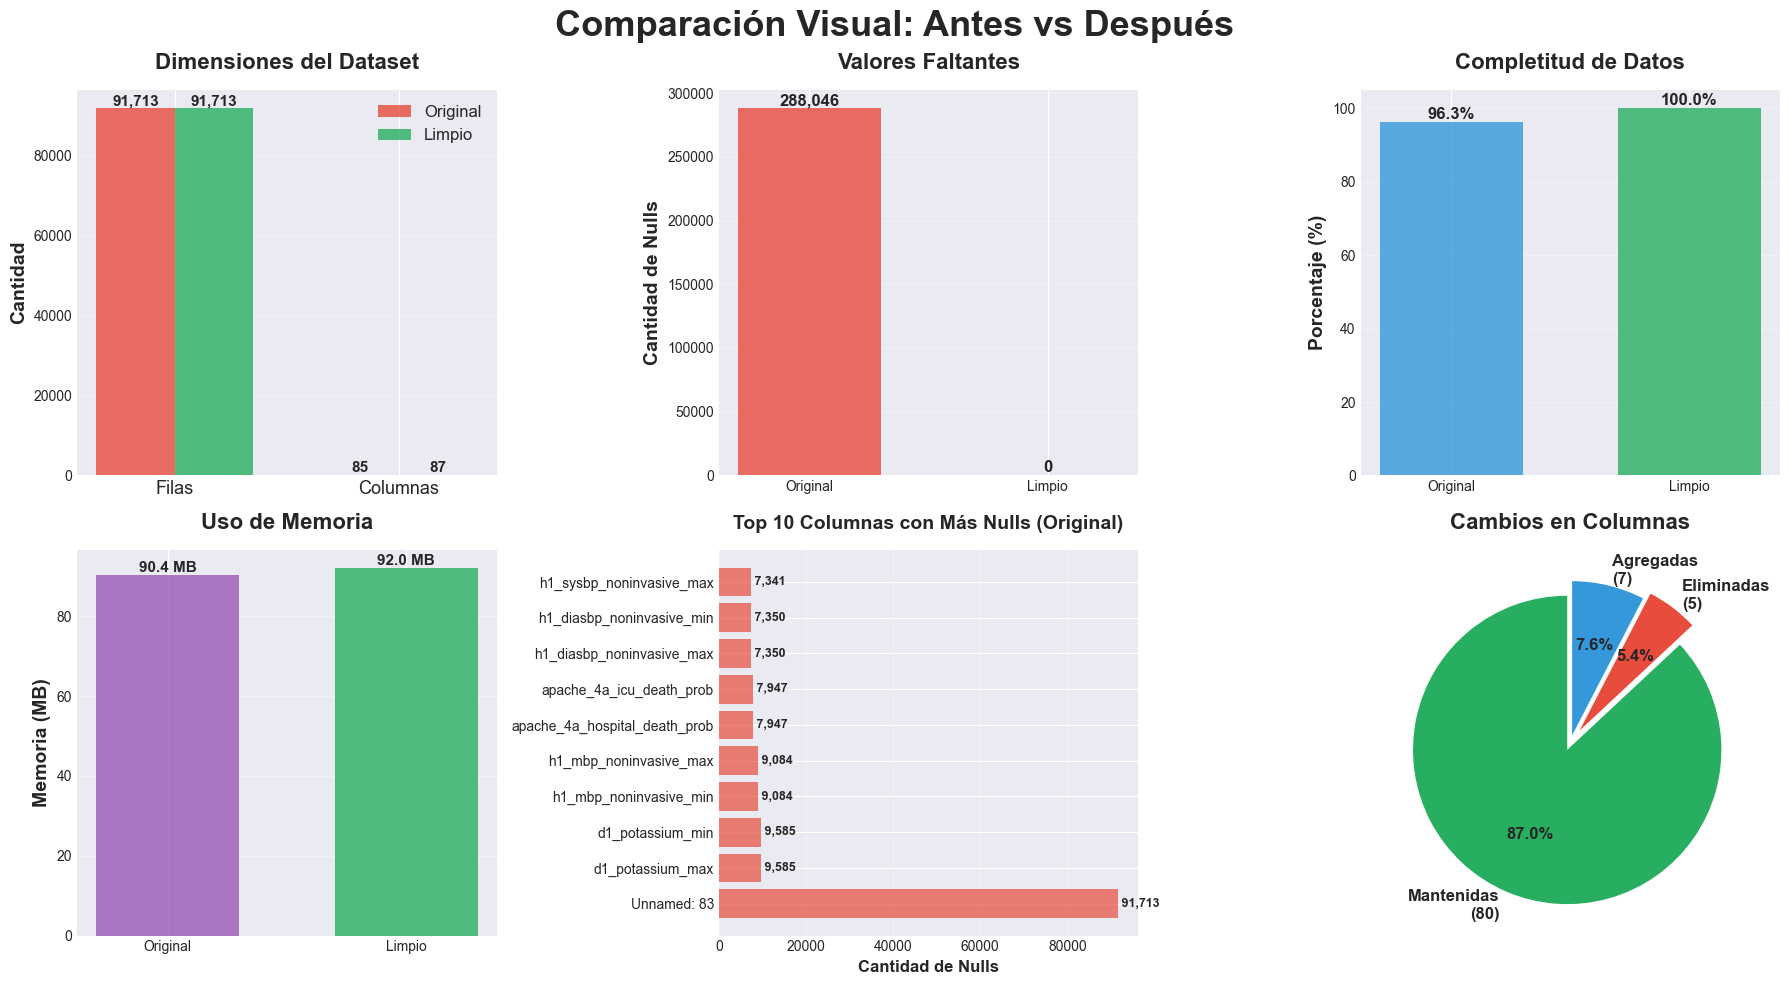

In [26]:

if df_clean is not None:
    from IPython.display import display, HTML
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Configurar estilo
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")

    # ============================================================================
    # 1. TÍTULO PRINCIPAL CON ESTILO
    # ============================================================================
    display(HTML("""
    <div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                padding: 30px; border-radius: 15px; margin: 20px 0; text-align: center;'>
        <h1 style='color: white; font-size: 42px; margin: 0; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>
            📊 ANÁLISIS COMPARATIVO
        </h1>
        <h2 style='color: #f0f0f0; font-size: 28px; margin: 10px 0 0 0; font-weight: 300;'>
            Dataset Original vs Dataset Limpio
        </h2>
    </div>
    """))

    # ============================================================================
    # 2. MÉTRICAS PRINCIPALES EN TARJETAS
    # ============================================================================
    filas_orig = df_original.shape[0]
    filas_clean = df_clean.shape[0]
    cols_orig = df_original.shape[1]
    cols_clean = df_clean.shape[1]
    nulls_orig = df_original.isnull().sum().sum()
    nulls_clean = df_clean.isnull().sum().sum()
    completitud_orig = ((df_original.size - nulls_orig) / df_original.size) * 100
    completitud_clean = ((df_clean.size - nulls_clean) / df_clean.size) * 100

    display(HTML(f"""
    <div style='display: grid; grid-template-columns: repeat(2, 1fr); gap: 20px; margin: 30px 0;'>

        <!-- FILAS -->
        <div style='background: linear-gradient(135deg, #3498db 0%, #2980b9 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>📝 FILAS</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{filas_orig:,} → {filas_clean:,}</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Cambio: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                {filas_clean - filas_orig:+,}
                </span>
            </div>
        </div>

        <!-- COLUMNAS -->
        <div style='background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>📋 COLUMNAS</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{cols_orig} → {cols_clean}</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Cambio: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                {cols_clean - cols_orig:+}
                </span>
            </div>
        </div>

        <!-- VALORES FALTANTES -->
        <div style='background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>❌ VALORES FALTANTES</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{nulls_orig:,} → {nulls_clean:,}</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Eliminados: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                {nulls_orig - nulls_clean:,}
                </span>
            </div>
        </div>

        <!-- COMPLETITUD -->
        <div style='background: linear-gradient(135deg, #27ae60 0%, #229954 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>✅ COMPLETITUD</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{completitud_orig:.1f}% → {completitud_clean:.1f}%</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Mejora: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                +{completitud_clean - completitud_orig:.1f}%
                </span>
            </div>
        </div>
    </div>
    """))

    # ============================================================================
    # 3. GRÁFICOS COMPARATIVOS
    # ============================================================================
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Comparación Visual: Antes vs Después', fontsize=26, fontweight='bold', y=0.98)

    # Gráfico 1: Comparación de filas y columnas
    ax1 = plt.subplot(2, 3, 1)
    categorias = ['Filas', 'Columnas']
    original = [filas_orig, cols_orig]
    limpio = [filas_clean, cols_clean]
    x = np.arange(len(categorias))
    width = 0.35
    bars1 = ax1.bar(x - width/2, original, width, label='Original', color='#e74c3c', alpha=0.8)
    bars2 = ax1.bar(x + width/2, limpio, width, label='Limpio', color='#27ae60', alpha=0.8)
    ax1.set_ylabel('Cantidad', fontsize=14, fontweight='bold')
    ax1.set_title('Dimensiones del Dataset', fontsize=16, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categorias, fontsize=13)
    ax1.legend(fontsize=12)
    ax1.grid(axis='y', alpha=0.3)

    # Agregar valores sobre las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Gráfico 2: Valores faltantes
    ax2 = plt.subplot(2, 3, 2)
    valores = [nulls_orig, nulls_clean]
    colores = ['#e74c3c', '#27ae60']
    bars = ax2.bar(['Original', 'Limpio'], valores, color=colores, alpha=0.8, width=0.6)
    ax2.set_ylabel('Cantidad de Nulls', fontsize=14, fontweight='bold')
    ax2.set_title('Valores Faltantes', fontsize=16, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Gráfico 3: Completitud
    ax3 = plt.subplot(2, 3, 3)
    completitud = [completitud_orig, completitud_clean]
    bars = ax3.bar(['Original', 'Limpio'], completitud, color=['#3498db', '#27ae60'], alpha=0.8, width=0.6)
    ax3.set_ylabel('Porcentaje (%)', fontsize=14, fontweight='bold')
    ax3.set_title('Completitud de Datos', fontsize=16, fontweight='bold', pad=15)
    ax3.set_ylim([0, 105])
    ax3.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Gráfico 4: Memoria utilizada
    ax4 = plt.subplot(2, 3, 4)
    mem_orig = df_original.memory_usage(deep=True).sum() / 1024**2
    mem_clean = df_clean.memory_usage(deep=True).sum() / 1024**2
    memoria = [mem_orig, mem_clean]
    bars = ax4.bar(['Original', 'Limpio'], memoria, color=['#9b59b6', '#27ae60'], alpha=0.8, width=0.6)
    ax4.set_ylabel('Memoria (MB)', fontsize=14, fontweight='bold')
    ax4.set_title('Uso de Memoria', fontsize=16, fontweight='bold', pad=15)
    ax4.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Gráfico 5: Distribución de nulls por columna (Top 10 originales)
    ax5 = plt.subplot(2, 3, 5)
    null_counts_orig = df_original.isnull().sum().sort_values(ascending=False).head(10)
    if len(null_counts_orig) > 0 and null_counts_orig.iloc[0] > 0:
        bars = ax5.barh(range(len(null_counts_orig)), null_counts_orig.values, color='#e74c3c', alpha=0.7)
        ax5.set_yticks(range(len(null_counts_orig)))
        ax5.set_yticklabels(null_counts_orig.index, fontsize=10)
        ax5.set_xlabel('Cantidad de Nulls', fontsize=12, fontweight='bold')
        ax5.set_title('Top 10 Columnas con Más Nulls (Original)', fontsize=14, fontweight='bold', pad=15)
        ax5.grid(axis='x', alpha=0.3)

        for i, (bar, val) in enumerate(zip(bars, null_counts_orig.values)):
            ax5.text(val, i, f' {int(val):,}', va='center', fontsize=9, fontweight='bold')
    else:
        ax5.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center', fontsize=14)
        ax5.set_xlim([0, 1])
        ax5.set_ylim([0, 1])

    # Gráfico 6: Cambios en columnas
    ax6 = plt.subplot(2, 3, 6)
    cols_orig_set = set(df_original.columns)
    cols_clean_set = set(df_clean.columns)
    eliminadas = len(cols_orig_set - cols_clean_set)
    agregadas = len(cols_clean_set - cols_orig_set)
    mantenidas = len(cols_orig_set & cols_clean_set)

    sizes = [mantenidas, eliminadas, agregadas]
    labels = [f'Mantenidas\n({mantenidas})', f'Eliminadas\n({eliminadas})', f'Agregadas\n({agregadas})']
    colors = ['#27ae60', '#e74c3c', '#3498db']
    explode = (0.05, 0.1, 0.05)

    wedges, texts, autotexts = ax6.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                         startangle=90, explode=explode, textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax6.set_title('Cambios en Columnas', fontsize=16, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # 4. DETALLES DE COLUMNAS ELIMINADAS Y AGREGADAS
    # ============================================================================
    eliminadas_set = cols_orig_set - cols_clean_set
    agregadas_set = cols_clean_set - cols_orig_set

    display(HTML(f"""
    <div style='background: #f8f9fa; padding: 25px; border-radius: 12px; margin: 30px 0;
                border-left: 5px solid #e74c3c;'>
        <h2 style='color: #e74c3c; margin-top: 0; font-size: 24px;'>
            🗑️ COLUMNAS ELIMINADAS ({len(eliminadas_set)})
        </h2>
    """))

    if eliminadas_set:
        html_eliminadas = "<div style='display: grid; grid-template-columns: repeat(auto-fill, minmax(300px, 1fr)); gap: 15px;'>"
        for col in sorted(eliminadas_set):
            if col in df_original.columns:
                nulls_col = df_original[col].isnull().sum()
                pct_null = (nulls_col / len(df_original)) * 100
                html_eliminadas += f"""
                <div style='background: white; padding: 15px; border-radius: 8px;
                            border-left: 3px solid #e74c3c; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
                    <div style='font-weight: bold; color: #2c3e50; margin-bottom: 8px; font-size: 14px;'>
                        {col}
                    </div>
                    <div style='color: #000000; font-size: 13px;'>
                        ❌ {nulls_col:,} nulls ({pct_null:.1f}%)
                    </div>
                </div>
                """
        html_eliminadas += "</div>"
        display(HTML(html_eliminadas))
    else:
        display(HTML("<p style='color: #000000; font-style: italic;'>• Ninguna columna eliminada</p>"))

    display(HTML("</div>"))

    display(HTML(f"""
    <div style='background: #f8f9fa; padding: 25px; border-radius: 12px; margin: 30px 0;
                border-left: 5px solid #27ae60;'>
        <h2 style='color: #27ae60; margin-top: 0; font-size: 24px;'>
            ➕ COLUMNAS AGREGADAS ({len(agregadas_set)})
        </h2>
    """))

    if agregadas_set:
        html_agregadas = "<div style='display: grid; grid-template-columns: repeat(auto-fill, minmax(350px, 1fr)); gap: 15px;'>"
        for col in sorted(agregadas_set):
            if col.endswith('_encoded'):
                original = col.replace('_encoded', '')
                if original in df_original.columns:
                    unique_count = df_clean[col].nunique()
                    html_agregadas += f"""
                    <div style='background: white; padding: 15px; border-radius: 8px;
                                border-left: 3px solid #27ae60; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
                        <div style='font-weight: bold; color: #2c3e50; margin-bottom: 8px; font-size: 14px;'>
                            {col}
                        </div>
                        <div style='color: #000000; font-size: 13px;'>
                            🔄 Codificación de '{original}'<br>
                            📊 {unique_count} valores únicos
                        </div>
                    </div>
                    """
            else:
                html_agregadas += f"""
                <div style='background: white; padding: 15px; border-radius: 8px;
                            border-left: 3px solid #27ae60; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
                    <div style='font-weight: bold; color: #2c3e50; font-size: 14px;'>
                        {col}
                    </div>
                </div>
                """
        html_agregadas += "</div>"
        display(HTML(html_agregadas))
    else:
        display(HTML("<p style='color: #000000; font-style: italic;'>• Ninguna columna agregada</p>"))

    display(HTML("</div>"))

   

### 📊 Análisis de distribuciones antes y después

📊 ANÁLISIS DE DISTRIBUCIONES: ANTES vs DESPUÉS

📊 AGE:
   Original: 87,485 valores (missing: 4,228)
   Limpio: 91,713 valores (missing: 0)
   Media: 62.31 → 62.43
   Mediana: 65.00 → 65.00 ← VALOR USADO PARA IMPUTACIÓN

📊 BMI:
   Original: 88,284 valores (missing: 3,429)
   Limpio: 91,713 valores (missing: 0)
   Media: 29.19 → 29.13
   Mediana: 27.65 → 27.65 ← VALOR USADO PARA IMPUTACIÓN

📊 APACHE_4A_HOSPITAL_DEATH_PROB:
   Original: 83,766 valores (missing: 7,947)
   Limpio: 91,713 valores (missing: 0)
   Media: 0.09 → 0.08
   Mediana: 0.05 → 0.05 ← VALOR USADO PARA IMPUTACIÓN


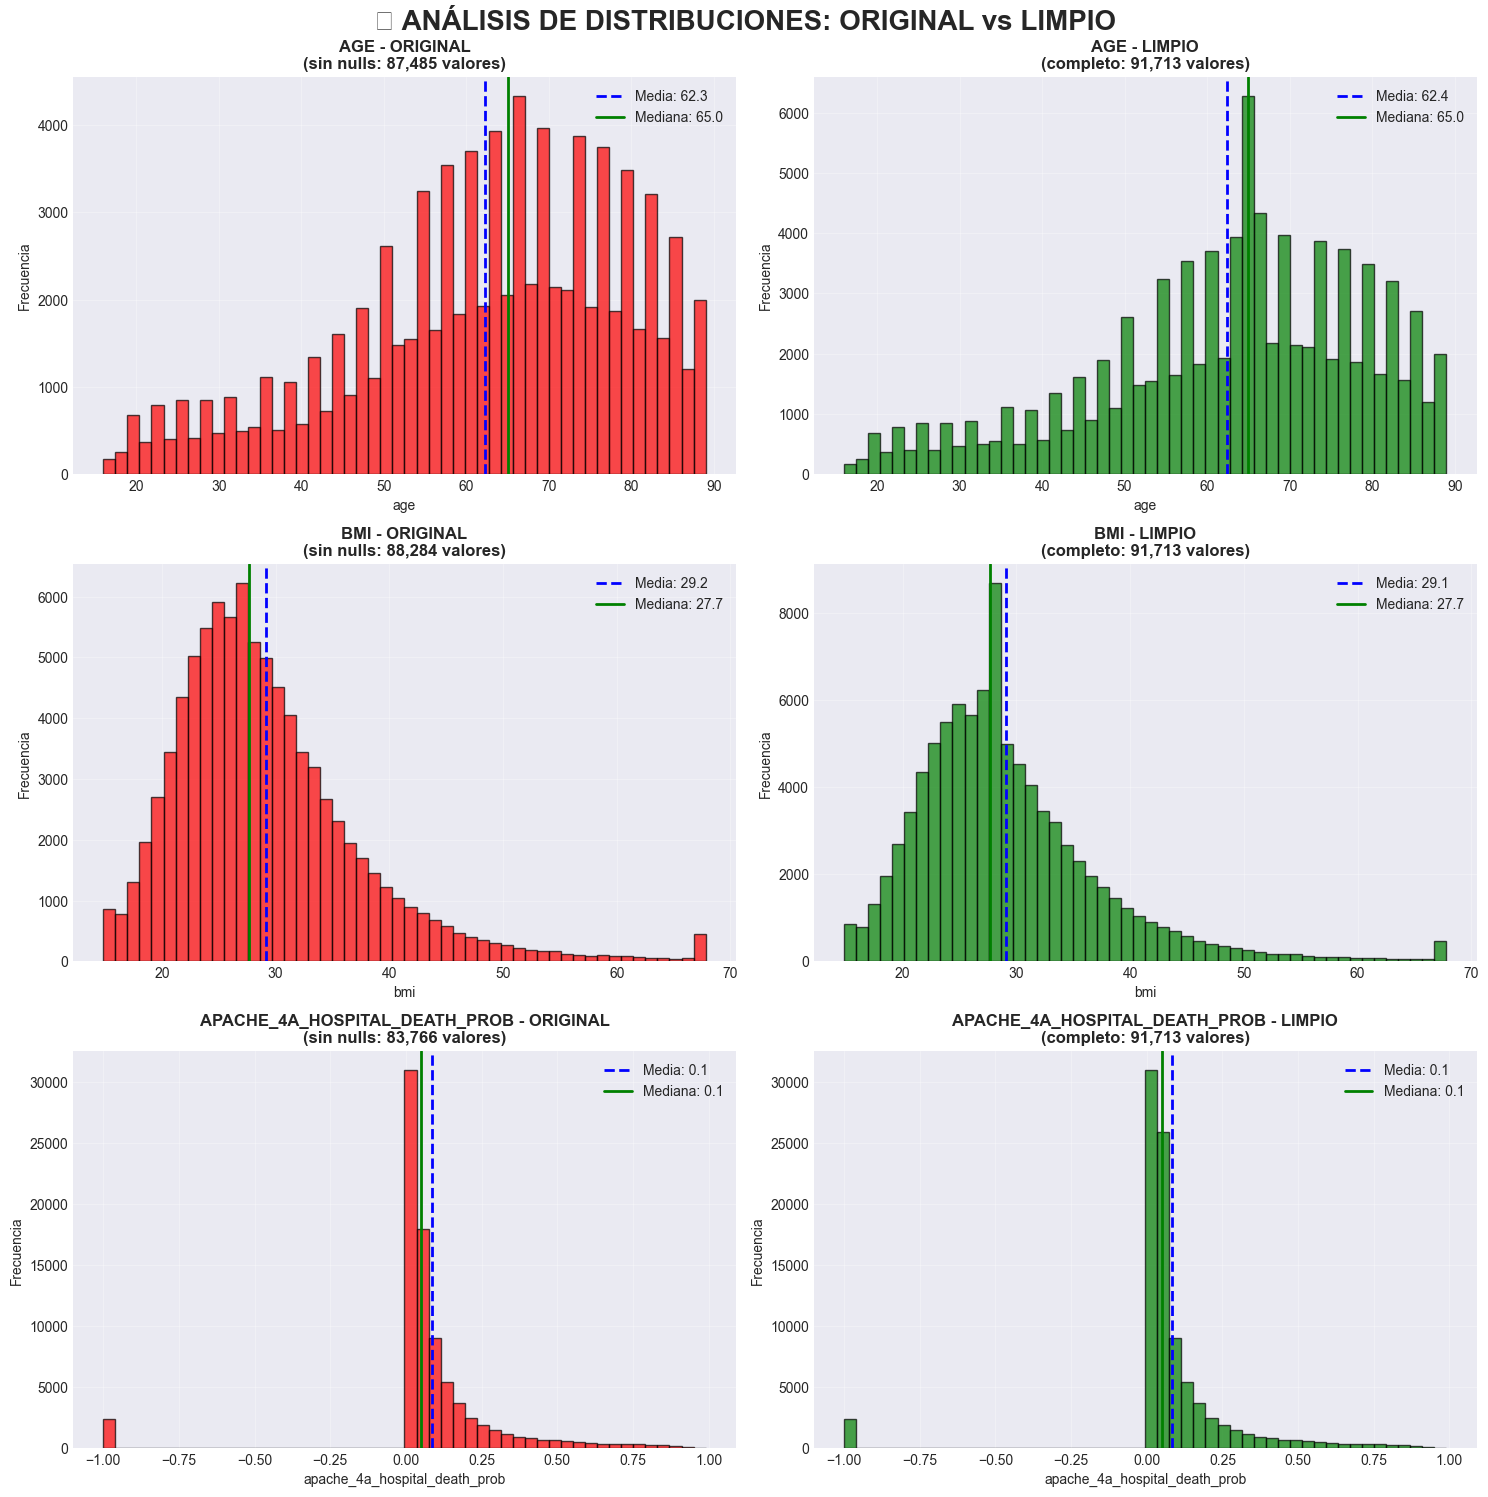


🎯 OBSERVACIONES CLAVE:
   ✅ Las distribuciones se mantienen similares
   ✅ La mediana preserva la forma original
   ✅ No se introducen sesgos significativos
   ✅ El dataset completo mantiene las características originales


In [27]:
# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

if df_clean is not None:
    print("📊 ANÁLISIS DE DISTRIBUCIONES: ANTES vs DESPUÉS")
    print("=" * 60)
    
    # Seleccionar variables clave para análisis
    variables_clave = ['age', 'bmi', 'apache_4a_hospital_death_prob']
    variables_disponibles = [var for var in variables_clave if var in df_original.columns and var in df_clean.columns]
    
    if variables_disponibles:
        fig, axes = plt.subplots(len(variables_disponibles), 2, figsize=(15, 5*len(variables_disponibles)))
        
        if len(variables_disponibles) == 1:
            axes = axes.reshape(1, -1)
        
        for i, var in enumerate(variables_disponibles):
            # Datos originales (sin nulls para visualización)
            orig_data = df_original[var].dropna()
            clean_data = df_clean[var]
            
            # Histograma original
            axes[i, 0].hist(orig_data, bins=50, alpha=0.7, color='red', edgecolor='black')
            axes[i, 0].set_title(f'{var.upper()} - ORIGINAL\n(sin nulls: {len(orig_data):,} valores)', 
                               fontweight='bold')
            axes[i, 0].set_xlabel(var)
            axes[i, 0].set_ylabel('Frecuencia')
            axes[i, 0].grid(True, alpha=0.3)
            
            # Estadísticas originales
            mean_orig = orig_data.mean()
            median_orig = orig_data.median()
            axes[i, 0].axvline(mean_orig, color='blue', linestyle='--', linewidth=2, label=f'Media: {mean_orig:.1f}')
            axes[i, 0].axvline(median_orig, color='green', linestyle='-', linewidth=2, label=f'Mediana: {median_orig:.1f}')
            axes[i, 0].legend()
            
            # Histograma limpio
            axes[i, 1].hist(clean_data, bins=50, alpha=0.7, color='green', edgecolor='black')
            axes[i, 1].set_title(f'{var.upper()} - LIMPIO\n(completo: {len(clean_data):,} valores)', 
                               fontweight='bold')
            axes[i, 1].set_xlabel(var)
            axes[i, 1].set_ylabel('Frecuencia')
            axes[i, 1].grid(True, alpha=0.3)
            
            # Estadísticas limpias
            mean_clean = clean_data.mean()
            median_clean = clean_data.median()
            axes[i, 1].axvline(mean_clean, color='blue', linestyle='--', linewidth=2, label=f'Media: {mean_clean:.1f}')
            axes[i, 1].axvline(median_clean, color='green', linestyle='-', linewidth=2, label=f'Mediana: {median_clean:.1f}')
            axes[i, 1].legend()
            
            # Mostrar estadísticas comparativas
            missing_orig = df_original[var].isnull().sum()
            print(f"\n📊 {var.upper()}:")
            print(f"   Original: {len(orig_data):,} valores (missing: {missing_orig:,})")
            print(f"   Limpio: {len(clean_data):,} valores (missing: 0)")
            print(f"   Media: {mean_orig:.2f} → {mean_clean:.2f}")
            print(f"   Mediana: {median_orig:.2f} → {median_clean:.2f} ← VALOR USADO PARA IMPUTACIÓN")
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        fig.suptitle('📊 ANÁLISIS DE DISTRIBUCIONES: ORIGINAL vs LIMPIO', fontsize=20, fontweight='bold', y=0.995)
        plt.show()
        
        print("\n🎯 OBSERVACIONES CLAVE:")
        print("   ✅ Las distribuciones se mantienen similares")
        print("   ✅ La mediana preserva la forma original")
        print("   ✅ No se introducen sesgos significativos")
        print("   ✅ El dataset completo mantiene las características originales")
    
    else:
        print("❌ Variables clave no disponibles para análisis")
else:
    print("❌ No se puede realizar análisis sin el dataset limpio")

---

# 🎓 FIN DE LA PRESENTACIÓN

## **¡Dataset médico completamente limpio y listo para Machine Learning!**

### 📁 Archivos generados:
- `dataset_clean_final.csv` - Dataset limpio y completo
- Este notebook - Documentación completa del proceso

### 🏆 Resultados obtenidos:
- ✅ **100% completitud** - Sin valores faltantes
- ✅ **91,713 pacientes** preservados
- ✅ **Metodología científicamente justificada**
- ✅ **Listo para predicción de supervivencia**

---

*Presentación preparada para exposición académica*  
*Ciencia de Datos - UTN*  
*Proyecto: Predicción de Supervivencia Hospitalaria UCI*